# TASK 2: EXPLORATORY DATA ANALYSIS

## 1. Introduction

Exploratory Data Analysis (EDA) is the process of looking at a dataset before doing any modeling, to understand what is actually in it. The goal is to check the structure of the data, look for patterns, spot anything unusual, and get a sense of what questions the data can actually answer.

For this task, I am using the "Supermarket Sales" dataset published by Aung Pyae on Kaggle. It contains transaction-level sales records from three supermarket branches in Myanmar, with details like the product line purchased, the branch and city, the customer type, gender, payment method, quantities, prices, and a customer rating for each transaction. Since this is real transactional data (not a toy dataset built for teaching), it is a reasonable dataset to practice a full EDA workflow on.

## 2. Objective

The objective of this analysis is to explore the supermarket sales dataset in a structured way and answer practical questions about it, such as:

- Which branches, cities, and product lines perform better than others
- Whether customer type, gender, or payment method are related to spending
- Whether there are any patterns over time (day of week, date)
- Whether the numerical variables (price, quantity, total, rating) are related to each other
- Whether the dataset has any data quality issues that would need to be addressed before further analysis (e.g. modeling)

This is not meant to build a predictive model. It is meant to understand the data itself and document what is found, using actual calculations and visualizations rather than assumptions.

## 3. Dataset Source

Dataset: **Supermarket Sales** by Aung Pyae
Source: https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales

The dataset contains 1000 rows and 17 columns of supermarket transaction data from three branches (Yangon, Mandalay, and Naypyitaw).

## 4. Questions Before Analysis

Before touching the data, here are the questions I want this EDA to answer. These are not answered yet — they are just laid out so the rest of the analysis has a clear direction.

1. Which product lines generate the highest total sales, and which generate the lowest?
2. Do the three branches (A, B, C) differ in terms of total sales or number of transactions?
3. Is there a difference in average spending between Member and Normal customers?
4. Does gender show any relationship with the product lines purchased or the amount spent?
5. Which payment method is used the most, and does the payment method relate to transaction size?
6. How are Quantity and Total distributed, and is there a clear relationship between unit price, quantity, and total?
7. How are customer ratings distributed, and do ratings differ meaningfully across branches or product lines?
8. Are there any trends in sales across dates, or across the days of the week?
9. Are there outliers in Total, Unit price, Quantity, or gross income, and if so, do they look like genuine transactions or possible data problems?
10. Are there any data quality issues in the dataset (missing values, duplicates, inconsistent categories, impossible values) that need to be flagged?

## 5. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
%matplotlib inline

## 6. Load Dataset

The dataset needs to be downloaded from the Kaggle link above. On Kaggle it is provided as a single CSV file, usually named `supermarket_sales - Sheet1.csv` (some mirrors just call it `supermarket_sales.csv`).

**If running in Jupyter locally:** place the CSV file in the same folder as this notebook, and use the filename as it appears after download.

**If running in Google Colab:** either upload the file using the file upload button in the Colab sidebar, or mount Google Drive and point the path to wherever the file is stored.

The code below tries to load the file directly. If your filename is different, just change the string in `pd.read_csv()`.

In [8]:
# Adjust the filename/path below if your downloaded file is named differently
df = pd.read_csv("/Users/harshalpardeshi/Documents/Internship/Task1/supermarket_sales - Sheet1.csv")

# For Google Colab, if uploading manually, you can instead use:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv("supermarket_sales - Sheet1.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## 7. Initial Data Inspection

In [9]:
# First 5 rows
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [10]:
# Last 5 rows
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


In [11]:
# Shape of the dataset
df.shape

(1000, 17)

In [12]:
# Column names
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Total',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

In [13]:
# Data types
df.dtypes

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [15]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [16]:
# Summary of categorical columns
categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in categorical_cols:
    print(col, "->", df[col].nunique(), "unique values")
    print(df[col].unique())
    print()

Branch -> 3 unique values
<ArrowStringArray>
['A', 'C', 'B']
Length: 3, dtype: str

City -> 3 unique values
<ArrowStringArray>
['Yangon', 'Naypyitaw', 'Mandalay']
Length: 3, dtype: str

Customer type -> 2 unique values
<ArrowStringArray>
['Member', 'Normal']
Length: 2, dtype: str

Gender -> 2 unique values
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Product line -> 6 unique values
<ArrowStringArray>
[     'Health and beauty', 'Electronic accessories',     'Home and lifestyle',
      'Sports and travel',     'Food and beverages',    'Fashion accessories']
Length: 6, dtype: str

Payment -> 3 unique values
<ArrowStringArray>
['Ewallet', 'Cash', 'Credit card']
Length: 3, dtype: str



**Observations from initial inspection:**

The dataset has 1000 rows and 17 columns, and none of the numerical columns show missing values at this stage (checked properly in the next section). The columns are a mix of identifiers (`Invoice ID`), categorical fields (`Branch`, `City`, `Customer type`, `Gender`, `Product line`, `Payment`), numerical fields (`Unit price`, `Quantity`, `Tax 5%`, `Total`, `cogs`, `gross margin percentage`, `gross income`, `Rating`), and two columns that are stored as text but represent date/time (`Date`, `Time`) — these will need to be converted to proper datetime types before doing any time-based analysis.

Looking at `df.describe()`, the numerical columns look reasonable at first glance: `Rating` ranges from 4.0 to 10.0, `Quantity` ranges from 1 to 10 units per transaction, and `Unit price` ranges from about 10 to 100. Nothing in this first look screams "broken data", but that needs to be checked properly rather than assumed — which is what the Data Quality Check section is for.

The categorical columns confirm what the dataset description says: 3 branches (A, B, C) mapping to 3 cities (Yangon, Mandalay, Naypyitaw), 2 customer types (Member, Normal), 2 genders (Male, Female), 6 product lines, and 3 payment methods (Cash, Credit card, Ewallet). One thing worth noting for later: `gross margin percentage` appeared to be a fixed value across rows in this dataset, which is unusual for a real business metric — this will be looked at more closely in the Data Quality Check section instead of assuming it is a mistake.

## 8. Data Quality Check

In [17]:
# Missing values
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [18]:
# Duplicate rows (full row duplicates)
print("Full duplicate rows:", df.duplicated().sum())

# Duplicate Invoice IDs (each transaction should be unique)
print("Duplicate Invoice IDs:", df['Invoice ID'].duplicated().sum())

Full duplicate rows: 0
Duplicate Invoice IDs: 0


In [19]:
# Checking for negative or impossible values in key numeric columns
num_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross income', 'Rating']
for col in num_cols:
    print(col, "-> min:", df[col].min(), "| max:", df[col].max(), "| negative values:", (df[col] < 0).sum())

Unit price -> min: 10.08 | max: 99.96 | negative values: 0
Quantity -> min: 1 | max: 10 | negative values: 0
Tax 5% -> min: 0.5085 | max: 49.65 | negative values: 0
Total -> min: 10.6785 | max: 1042.65 | negative values: 0
cogs -> min: 10.17 | max: 993.0 | negative values: 0
gross income -> min: 0.5085 | max: 49.65 | negative values: 0
Rating -> min: 4.0 | max: 10.0 | negative values: 0


In [20]:
# Checking internal consistency: Total should equal Unit price * Quantity * 1.05 (5% tax)
calculated_total = df['Unit price'] * df['Quantity'] * 1.05
mismatch = (df['Total'] - calculated_total).abs() > 0.01
print("Rows where Total does not match Unit price * Quantity * 1.05:", mismatch.sum())

Rows where Total does not match Unit price * Quantity * 1.05: 0


In [21]:
# Checking categorical columns for inconsistent spelling/casing
categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in categorical_cols:
    print(col, ":", sorted(df[col].unique()))

Branch : ['A', 'B', 'C']
City : ['Mandalay', 'Naypyitaw', 'Yangon']
Customer type : ['Member', 'Normal']
Gender : ['Female', 'Male']
Product line : ['Electronic accessories', 'Fashion accessories', 'Food and beverages', 'Health and beauty', 'Home and lifestyle', 'Sports and travel']
Payment : ['Cash', 'Credit card', 'Ewallet']


In [22]:
# Checking Branch-City mapping is consistent (each branch should map to exactly one city)
df.groupby('Branch')['City'].unique()

Branch
A       [Yangon]
B     [Mandalay]
C    [Naypyitaw]
Name: City, dtype: object

In [23]:
# Checking the constant column noticed earlier
df['gross margin percentage'].unique()

array([4.76190476])

In [24]:
# Data types - Date and Time are read as text, not as actual date/time objects
df[['Date', 'Time']].dtypes

Date    str
Time    str
dtype: object

**Data quality summary:**

- No missing values anywhere in the dataset (`df.isnull().sum()` is 0 for all 17 columns).
- No duplicate rows and no duplicate `Invoice ID` values — every transaction is unique.
- No negative or otherwise impossible values in `Unit price`, `Quantity`, `Tax 5%`, `Total`, `cogs`, `gross income`, or `Rating`.
- `Total` is fully consistent with `Unit price x Quantity x 1.05` for every single row (max difference is essentially zero, just floating point rounding). Same for `gross income`, which equals `cogs x 0.05` exactly. This means `Tax 5%`, `Total`, `cogs`, and `gross income` are not independent pieces of information — they are all derived from `Unit price` and `Quantity`. This matters for the correlation analysis later, because a very high correlation between these columns does not really tell us anything new; it is just arithmetic.
- Each `Branch` maps to exactly one `City` (A -> Yangon, B -> Mandalay, C -> Naypyitaw), so there is no inconsistency there.
- `gross margin percentage` is a constant value (4.761905) for all 1000 rows. This is not a calculation error in the data — it looks like the dataset creator applied a single fixed margin assumption to every transaction rather than it being an actually measured value. Because it carries no variation, it is not useful for analysis and will be excluded from further exploration.
- `Date` and `Time` are stored as text (object/string) rather than proper datetime types. This is not a data quality issue with the data itself, but it needs to be fixed before any time-based analysis, which is done in Section 11.

Overall, this dataset is unusually clean for a "real-world" dataset — likely because it was prepared/cleaned before being published on Kaggle. The main things to keep in mind going forward are the fully-dependent tax/cogs/income columns and the constant margin column, not missing data or errors.

## 9. Univariate Analysis

### Numerical Variables

In [25]:
df[['Total', 'Quantity', 'Unit price', 'Rating', 'gross income']].describe()

,Total,Quantity,Unit price,Rating,gross income
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,322.966749,5.510000,55.672130,6.97270,15.379369
std,245.885335,2.923431,26.494628,1.71858,11.708825
min,10.678500,1.000000,10.080000,4.00000,0.508500
25%,124.422375,3.000000,32.875000,5.50000,5.924875
50%,253.848000,5.000000,55.230000,7.00000,12.088000
75%,471.350250,8.000000,77.935000,8.50000,22.445250
max,1042.650000,10.000000,99.960000,10.00000,49.650000


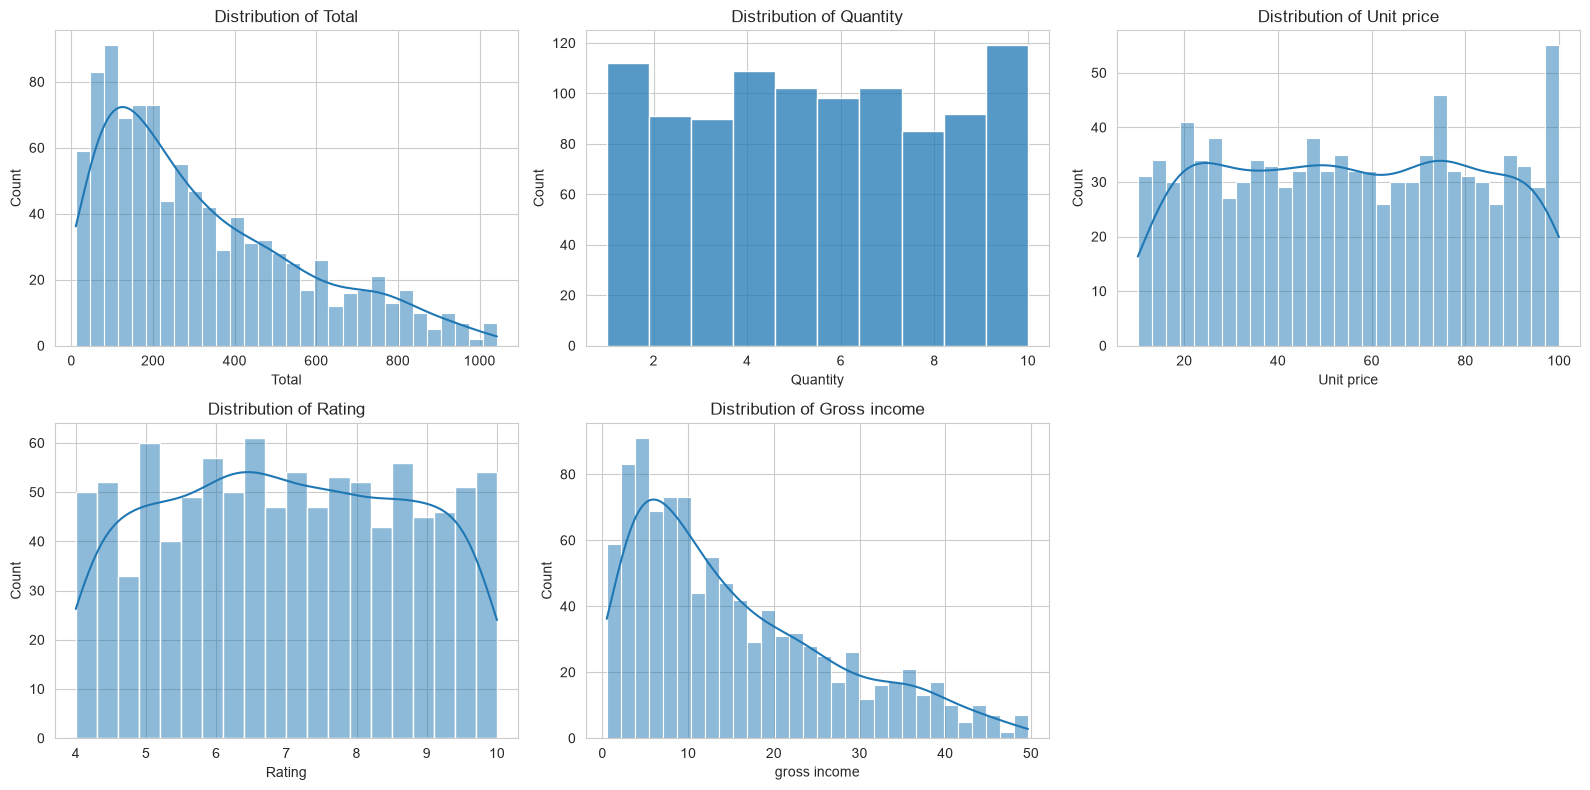

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.histplot(df['Total'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribution of Total')

sns.histplot(df['Quantity'], bins=10, kde=False, ax=axes[0,1])
axes[0,1].set_title('Distribution of Quantity')

sns.histplot(df['Unit price'], bins=30, kde=True, ax=axes[0,2])
axes[0,2].set_title('Distribution of Unit price')

sns.histplot(df['Rating'], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribution of Rating')

sns.histplot(df['gross income'], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title('Distribution of Gross income')

axes[1,2].axis('off')
plt.tight_layout()
plt.show()

The `Total` and `gross income` distributions are right-skewed (skewness around 0.89 for both) — most transactions are on the lower end, with a tail of larger transactions. This makes sense for retail: most people buy small-to-medium baskets, and a smaller number buy large quantities of expensive items, which pulls the tail out.

`Quantity` and `Unit price` are close to uniformly spread across their ranges (skewness near 0 for both), which suggests the dataset may have been generated or sampled in a way that spreads these values fairly evenly, rather than following a typical real-world purchasing pattern where small quantities dominate.

`Rating` is roughly centered around 7, with a standard deviation of about 1.7, and does not show any obvious skew.

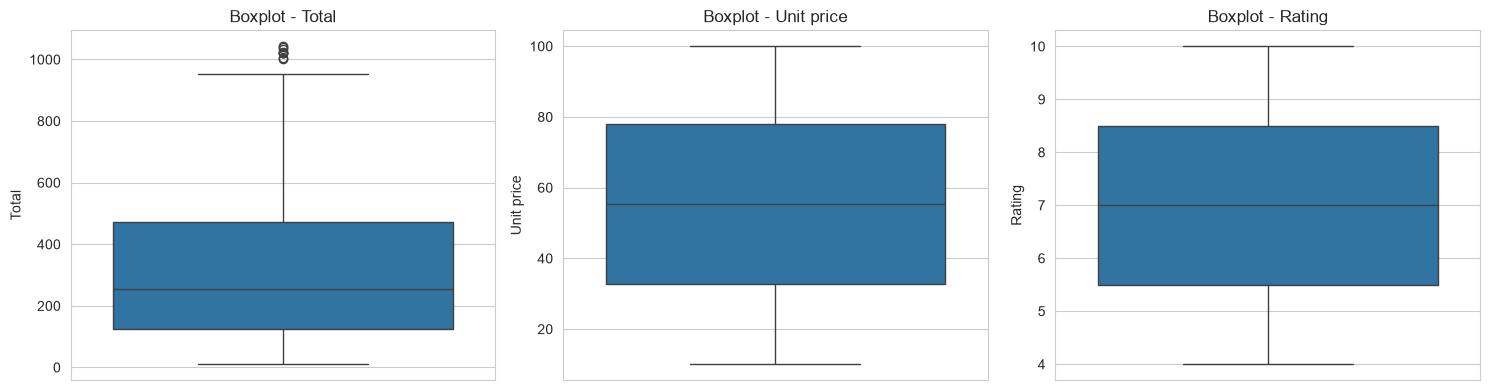

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['Total'], ax=axes[0])
axes[0].set_title('Boxplot - Total')

sns.boxplot(y=df['Unit price'], ax=axes[1])
axes[1].set_title('Boxplot - Unit price')

sns.boxplot(y=df['Rating'], ax=axes[2])
axes[2].set_title('Boxplot - Rating')

plt.tight_layout()
plt.show()

The boxplot for `Total` shows a number of points above the upper whisker — these are the higher-value transactions, which will be looked at properly in the Outlier Detection section. `Unit price` and `Rating` do not show any points outside their whiskers, so there is nothing unusual there.

### Categorical Variables

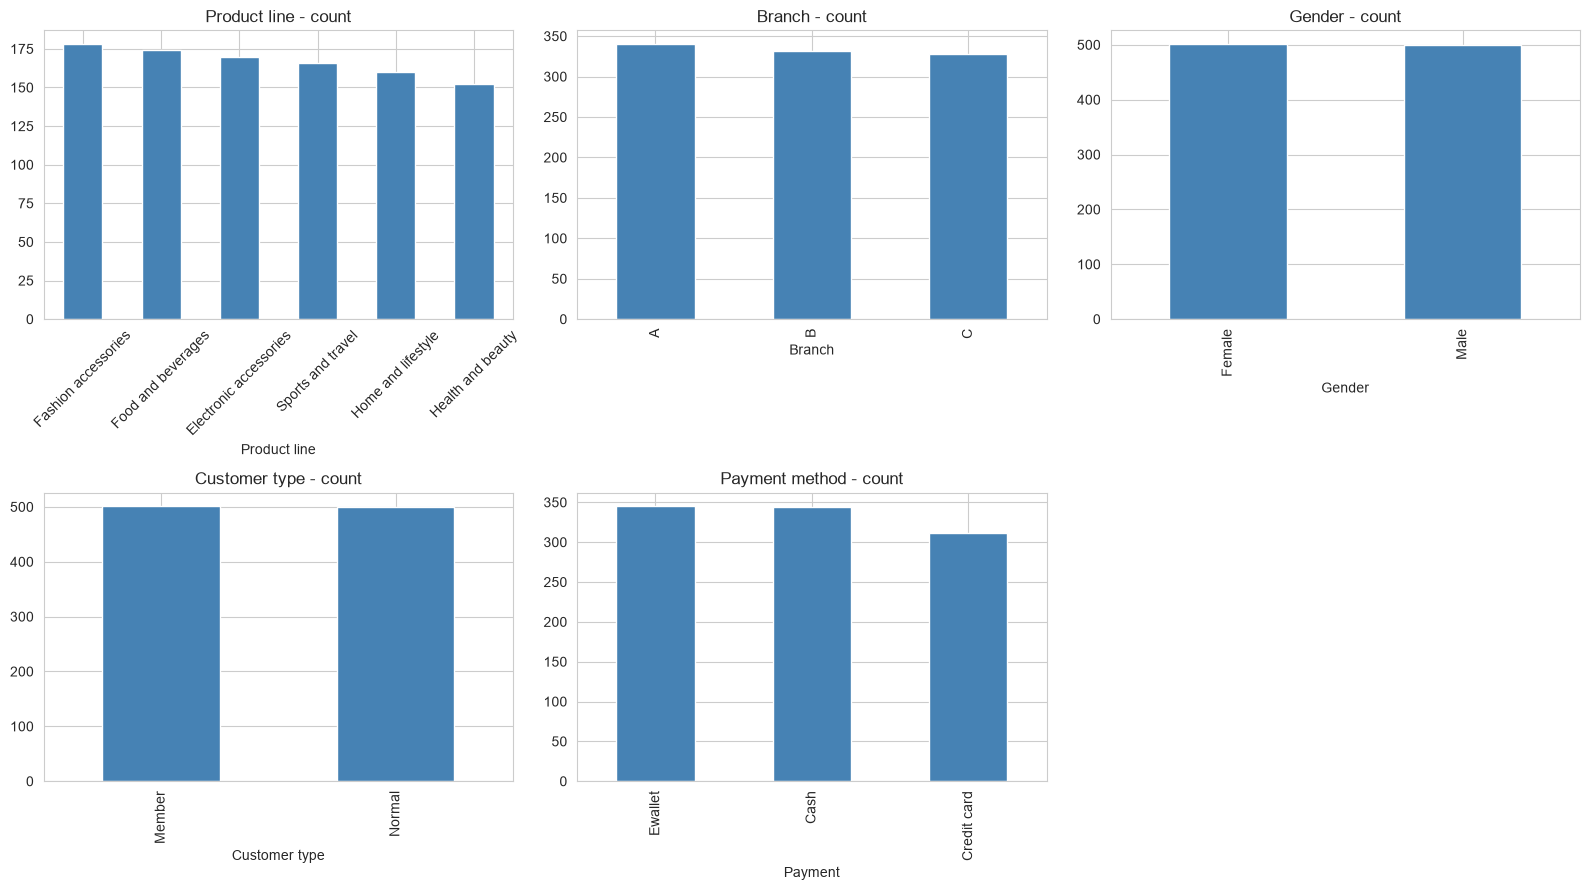

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

df['Product line'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Product line - count')
axes[0,0].tick_params(axis='x', rotation=45)

df['Branch'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Branch - count')

df['Gender'].value_counts().plot(kind='bar', ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Gender - count')

df['Customer type'].value_counts().plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Customer type - count')

df['Payment'].value_counts().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Payment method - count')

axes[1,2].axis('off')
plt.tight_layout()
plt.show()

The number of transactions is close to evenly split across almost every categorical variable: Branch A/B/C are 340/332/328, Gender is 501/499 (Female/Male), and Customer type is 501/499 (Member/Normal). `Product line` ranges from 152 (Health and beauty) to 178 (Fashion accessories) transactions, and `Payment` ranges from 311 (Credit card) to 345 (Ewallet). None of these differences look large enough to call one category dramatically more common than another — this dataset looks like it may have been balanced somewhat deliberately rather than reflecting completely organic transaction volume.

## 10. Bivariate Analysis

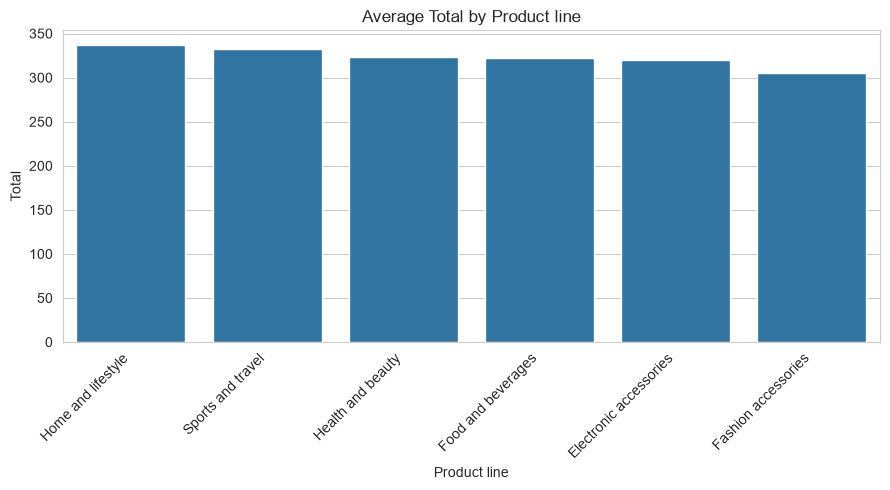

In [29]:
plt.figure(figsize=(9,5))
order = df.groupby('Product line')['Total'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Product line', y='Total', order=order, estimator='mean', errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title('Average Total by Product line')
plt.tight_layout()
plt.show()

Average `Total` per transaction across product lines is fairly close together, ranging from about 305 (Fashion accessories) to about 337 (Home and lifestyle). This is only around a 10% difference between the highest and lowest, so no single product line stands out as dramatically more profitable per transaction than the others.

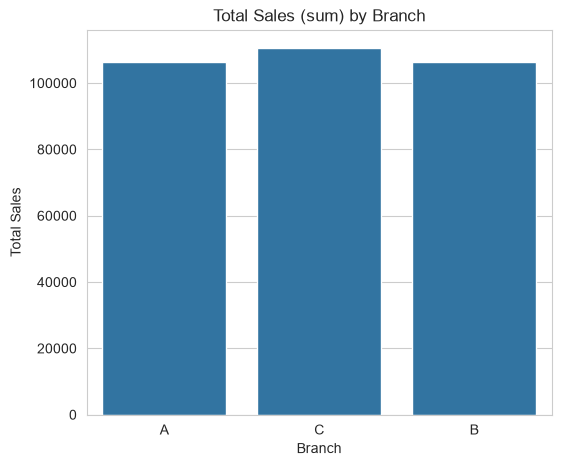

In [30]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='Branch', y='Total', estimator='sum', errorbar=None)
plt.title('Total Sales (sum) by Branch')
plt.ylabel('Total Sales')
plt.show()

Branch C (Naypyitaw) has the highest total sales (about 110,569), followed by Branch A (about 106,200) and Branch B (about 106,198). The gap between branches is small — about 4% between the highest and lowest — so branches are performing at a broadly similar level rather than one clearly outperforming the others.

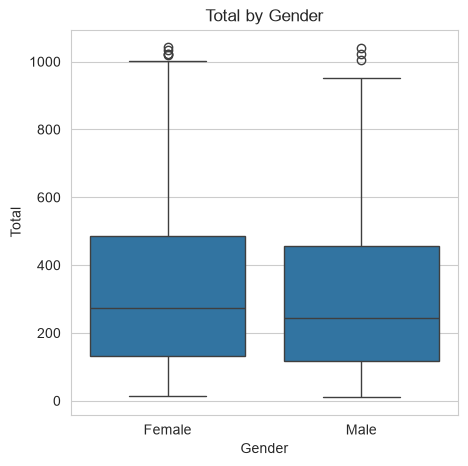

In [31]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df, x='Gender', y='Total')
plt.title('Total by Gender')
plt.show()

Female customers have a slightly higher average `Total` (about 335) than male customers (about 311), but the boxplots overlap heavily. Whether this difference is statistically meaningful is checked properly in the Hypothesis Testing section, rather than concluded here just from the chart.

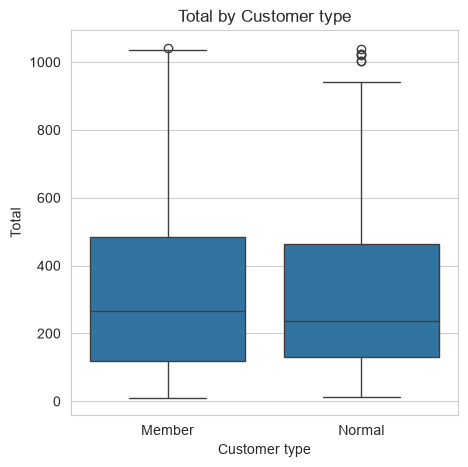

In [32]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df, x='Customer type', y='Total')
plt.title('Total by Customer type')
plt.show()

Members have a slightly higher average `Total` (about 328) than Normal customers (about 318), which is again a small difference that overlaps a lot on the boxplot. This is also tested formally later.

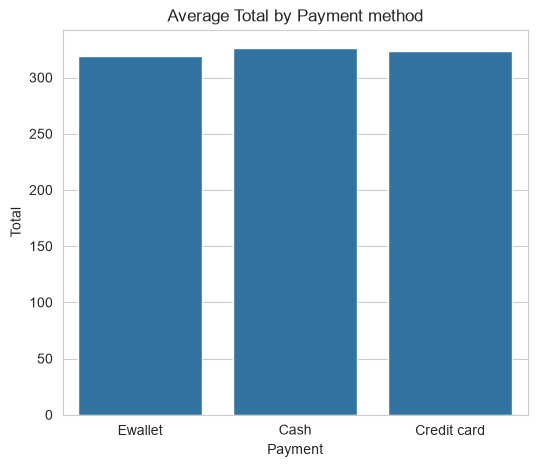

In [33]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x='Payment', y='Total', estimator='mean', errorbar=None)
plt.title('Average Total by Payment method')
plt.show()

Average `Total` by payment method is nearly identical across Cash (about 326), Credit card (about 324), and Ewallet (about 319) — a difference of less than 3% between the highest and lowest. Payment method does not appear to be related to transaction size in this dataset.

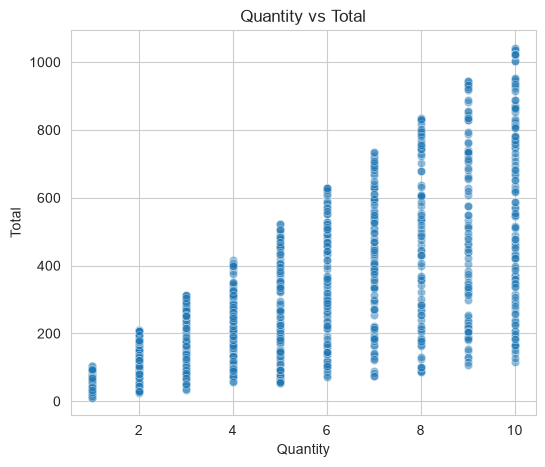

In [34]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Quantity', y='Total', alpha=0.5)
plt.title('Quantity vs Total')
plt.show()

There is a visible positive relationship between `Quantity` and `Total` — as expected, since `Total` is directly calculated from `Quantity` and `Unit price`. The correlation coefficient here is about 0.71, which is checked more formally in the Correlation Analysis section.

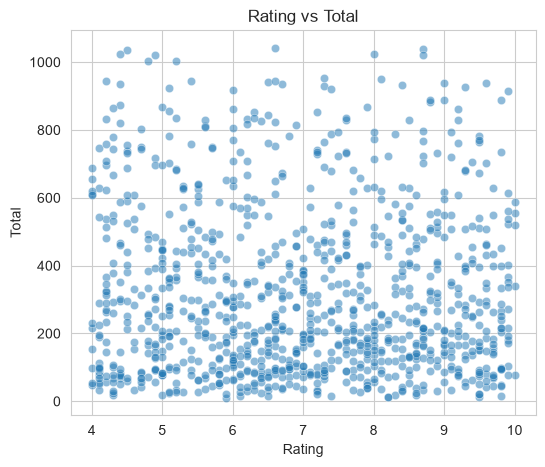

In [35]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Rating', y='Total', alpha=0.5)
plt.title('Rating vs Total')
plt.show()

There is no visible pattern between `Rating` and `Total` — the points are scattered with no clear trend. The correlation between them is close to zero (about -0.04), which suggests that how much a customer spends has no real relationship with how they rated the experience, at least in this dataset.

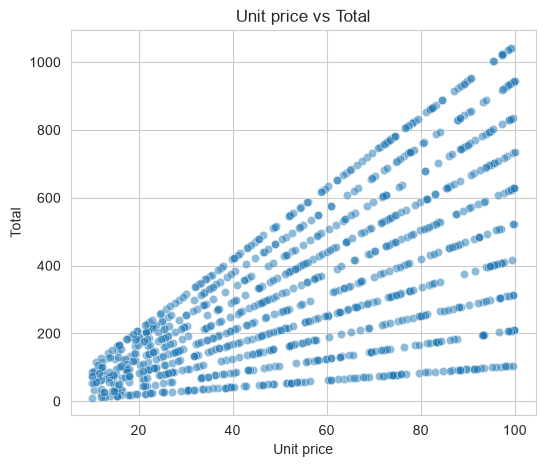

In [36]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Unit price', y='Total', alpha=0.5)
plt.title('Unit price vs Total')
plt.show()

`Unit price` also shows a positive relationship with `Total` (correlation about 0.63), which again follows directly from how `Total` is calculated. Both `Quantity` and `Unit price` contribute to `Total`, but `Quantity` has the stronger relationship of the two.

## 11. Time-Based Analysis

In [37]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')

df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month
df['Hour'] = df['Time'].dt.hour

print("Date range in the dataset:", df['Date'].min().date(), "to", df['Date'].max().date())

Date range in the dataset: 2019-01-01 to 2019-03-30


The dataset covers exactly 3 months: January 1, 2019 to March 30, 2019. This is a fairly short window, which is worth keeping in mind — 3 months is not really enough to identify seasonal patterns (like holidays), only short-term day-to-day or weekday patterns.

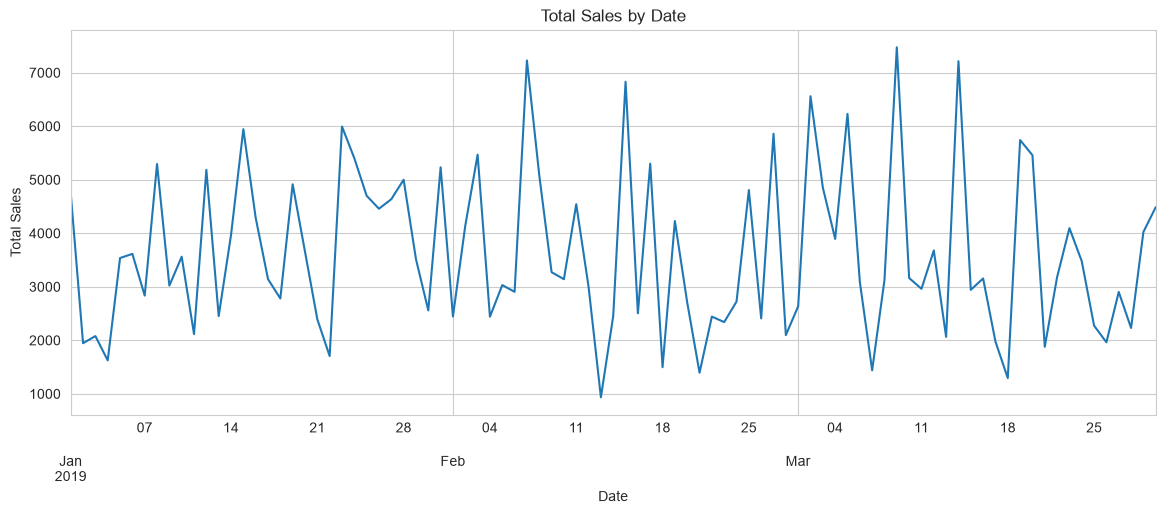

In [38]:
daily_sales = df.groupby('Date')['Total'].sum()

plt.figure(figsize=(14,5))
daily_sales.plot()
plt.title('Total Sales by Date')
plt.ylabel('Total Sales')
plt.xlabel('Date')
plt.show()

Daily total sales bounce around a lot, from a low of about 934 to a high of about 7,474 on a single day, with an average daily total of about 3,629. There is no obvious long-term upward or downward trend across the 3 months — it looks more like normal day-to-day fluctuation than a clear growth or decline pattern.

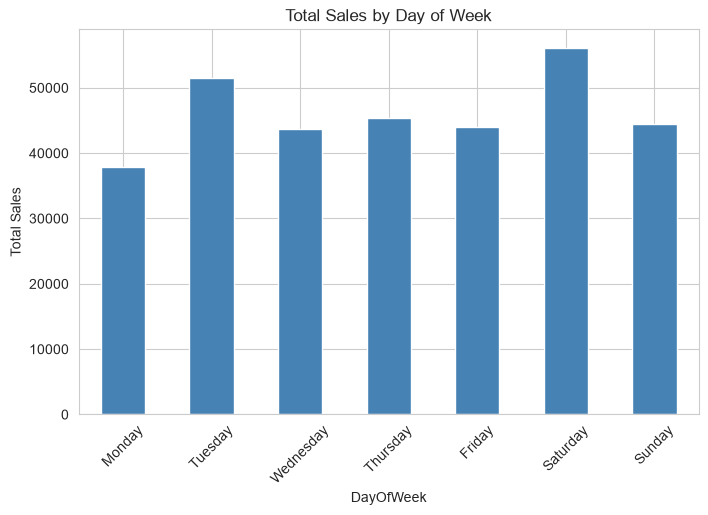

In [39]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sales_by_day = df.groupby('DayOfWeek')['Total'].sum().reindex(weekday_order)

plt.figure(figsize=(8,5))
sales_by_day.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Day of Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

Saturday has the highest total sales (about 56,121), and Monday has the lowest (about 37,899) — Saturday sales are close to 48% higher than Monday sales. This is a fairly clear pattern: weekends (especially Saturday) bring in more total revenue than the start of the week.

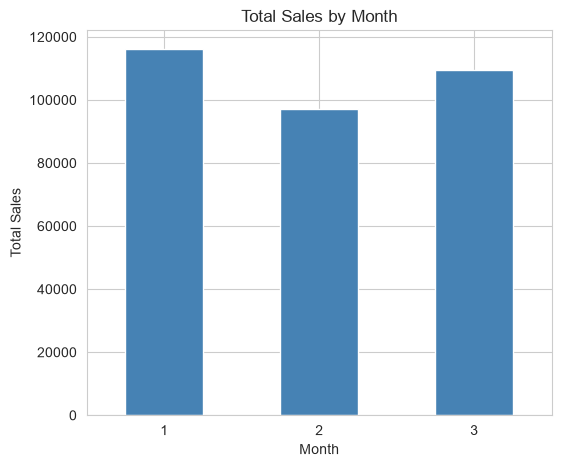

In [40]:
sales_by_month = df.groupby('Month')['Total'].sum()

plt.figure(figsize=(6,5))
sales_by_month.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

Month 1 (January) has the highest total sales (about 116,292), Month 2 (February) the lowest (about 97,219), and Month 3 (March) sits in between (about 109,456). With only 3 months of data, this is not enough to call this a "monthly trend" — it could just as easily be normal variation, or affected by February simply having fewer days.

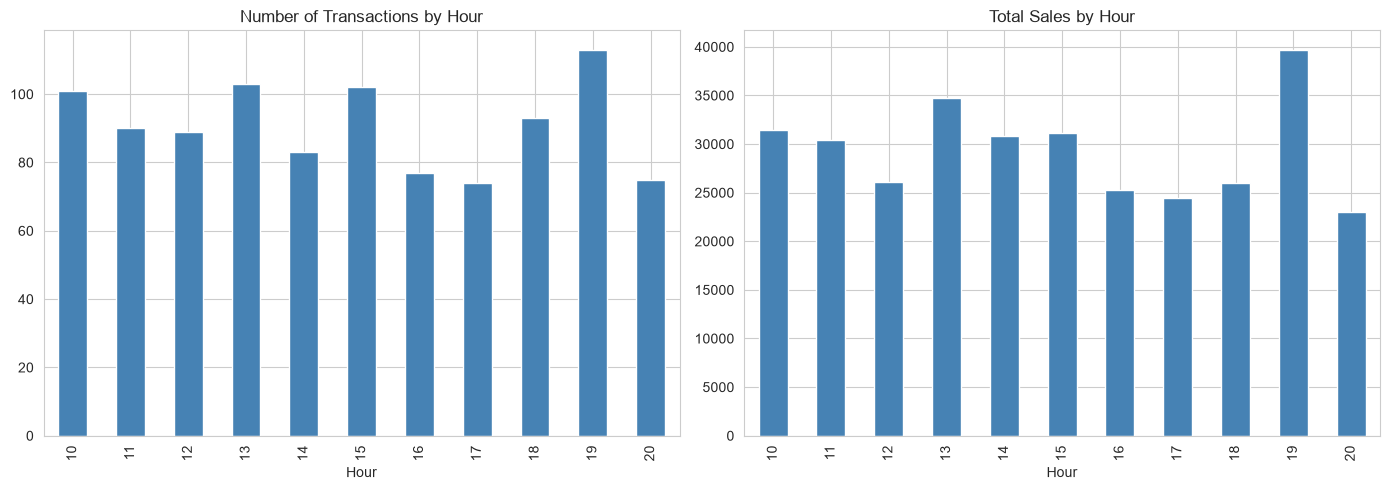

In [41]:
transactions_by_hour = df.groupby('Hour')['Total'].agg(['count','sum'])

fig, axes = plt.subplots(1,2, figsize=(14,5))
transactions_by_hour['count'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Transactions by Hour')

transactions_by_hour['sum'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Total Sales by Hour')
plt.tight_layout()
plt.show()

Transactions happen between 10:00 and 20:00 (the store's operating hours in this data). The busiest hour by number of transactions is 19:00 (113 transactions), and it also has the highest total sales (about 39,700) of any hour. There is a smaller secondary peak around 13:00 (103 transactions). The quietest hours are around 16:00-17:00 and 20:00 (closing time), which makes sense.

## 12. Correlation Analysis

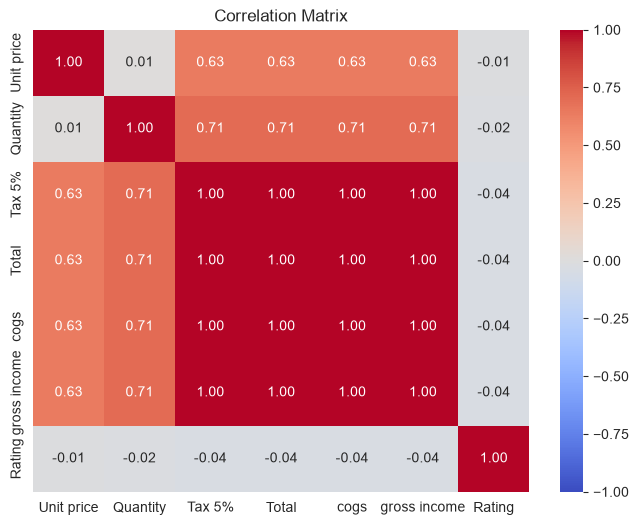

In [42]:
num_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross income', 'Rating']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

`Tax 5%`, `Total`, `cogs`, and `gross income` are all correlated with each other at 1.00. This is not a meaningful finding about customer behavior — it is simply because these four columns are all mathematically derived from `Unit price` and `Quantity` (as confirmed in the Data Quality Check). Reporting this as a "strong relationship" would be misleading, since it's really just the same information calculated four different ways.

The more meaningful correlations are:
- `Quantity` and `Total`: about 0.71 (moderate-to-strong positive) — buying more units leads to a higher total, which is expected.
- `Unit price` and `Total`: about 0.63 (moderate positive) — more expensive items also push the total up, though slightly less strongly than quantity does.
- `Unit price` and `Quantity`: about 0.01 (essentially no relationship) — customers do not seem to buy fewer expensive items or more cheap items; the two are independent of each other in this data.
- `Rating` has a very weak, close-to-zero correlation with every other numeric variable (around -0.01 to -0.04), meaning customer satisfaction (as measured by rating) does not track with how much they spent, how many items they bought, or how expensive the items were.

None of this implies causation — it just describes how these variables move together (or don't) in this dataset.

## 13. Outlier Detection

In [43]:
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)], lower, upper

for col in ['Total', 'Unit price', 'Quantity', 'gross income']:
    outliers, lower, upper = iqr_outliers(df[col])
    print(f"{col}: {len(outliers)} outlier(s) | IQR bounds: [{lower:.2f}, {upper:.2f}]")

Total: 9 outlier(s) | IQR bounds: [-395.97, 991.74]
Unit price: 0 outlier(s) | IQR bounds: [-34.72, 145.53]
Quantity: 0 outlier(s) | IQR bounds: [-4.50, 15.50]
gross income: 9 outlier(s) | IQR bounds: [-18.86, 47.23]


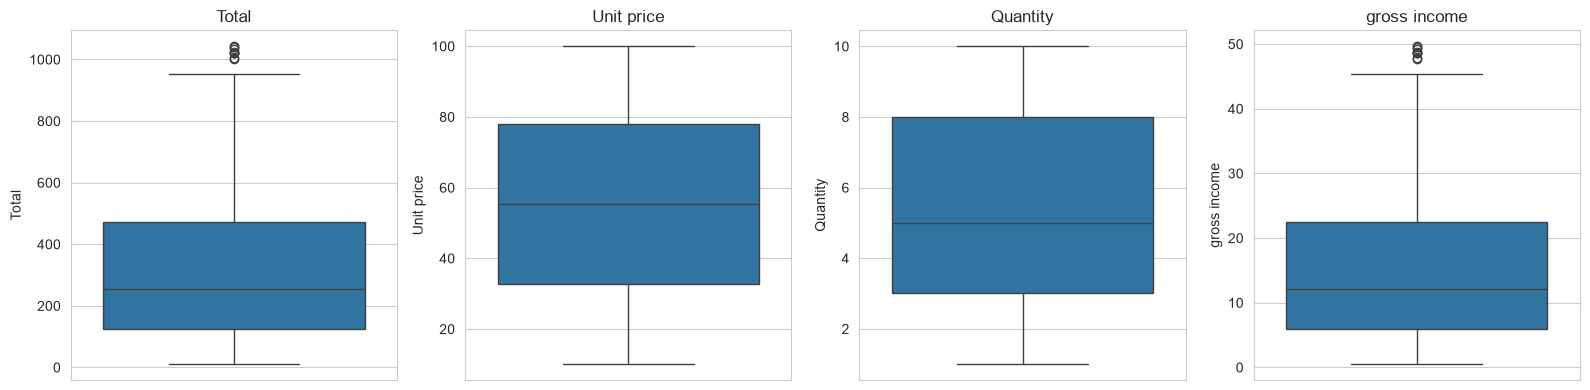

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, ['Total', 'Unit price', 'Quantity', 'gross income']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [45]:
total_outliers, _, upper_total = iqr_outliers(df['Total'])
df[df['Total'] > upper_total][['Invoice ID','Branch','Product line','Unit price','Quantity','Total','Payment']].sort_values('Total', ascending=False)

,Invoice ID,Branch,Product line,Unit price,Quantity,Total,Payment
350,860-79-0874,C,Fashion accessories,99.30,10,1042.650,Credit card
167,687-47-8271,A,Fashion accessories,98.98,10,1039.290,Credit card
557,283-26-5248,C,Food and beverages,98.52,10,1034.460,Ewallet
699,751-41-9720,C,Home and lifestyle,97.50,10,1023.750,Ewallet
996,303-96-2227,B,Home and lifestyle,97.38,10,1022.490,Ewallet
792,744-16-7898,B,Home and lifestyle,97.37,10,1022.385,Credit card
422,271-88-8734,C,Fashion accessories,97.21,10,1020.705,Credit card
166,234-65-2137,C,Home and lifestyle,95.58,10,1003.590,Cash
357,554-42-2417,C,Sports and travel,95.44,10,1002.120,Cash


Using the IQR method (1.5 x IQR beyond Q1/Q3):

- `Total`: 9 outliers, all above the upper bound (about 991.74). No values fall below the lower bound (which is actually negative and impossible to reach anyway, since `Total` cannot be negative).
- `gross income`: also 9 outliers, above an upper bound of about 47.23. This is the same 9 rows as the `Total` outliers, again because `gross income` is directly derived from the same underlying `Unit price x Quantity` calculation.
- `Unit price`: 0 outliers.
- `Quantity`: 0 outliers.

Looking at the actual 9 outlier rows, every single one has `Quantity` equal to 10 (the maximum possible quantity in this dataset) combined with a relatively high `Unit price`. These are not broken or suspicious values — they are legitimate large purchases (someone buying the maximum quantity of a moderately-to-highly priced item). Since the values are internally consistent (`Total` = `Unit price x Quantity x 1.05` holds exactly for these rows too) and nothing about them looks like a data-entry error, they are kept in the dataset rather than removed. Removing them would mean throwing away real information about high-value transactions.

## 14. Hypothesis Testing

### Hypothesis 1: Gender and spending (Total)

**Question:** Do male and female customers differ in how much they spend per transaction?

- H0: There is no difference in the average `Total` between male and female customers.
- H1: There is a difference in the average `Total` between male and female customers.

Before choosing a test, normality of `Total` within each gender group needs to be checked, since a standard t-test assumes roughly normal data.

In [46]:
male_total = df[df['Gender'] == 'Male']['Total']
female_total = df[df['Gender'] == 'Female']['Total']

# Shapiro-Wilk normality check (sampled to 500 per group, Shapiro is sensitive to large n)
stat_m, p_m = stats.shapiro(male_total.sample(min(len(male_total),500), random_state=1))
stat_f, p_f = stats.shapiro(female_total.sample(min(len(female_total),500), random_state=1))
print(f"Male Shapiro p-value: {p_m:.4e}")
print(f"Female Shapiro p-value: {p_f:.4e}")

Male Shapiro p-value: 8.5705e-18
Female Shapiro p-value: 9.5156e-16


Both p-values are far below 0.05, so the normality assumption does not hold for either group (this matches what was seen earlier — `Total` is right-skewed). Because of this, the **Mann-Whitney U test** (a non-parametric alternative to the independent t-test) is the appropriate choice here, since it does not assume normal distributions and instead compares the ranks of the two groups.

In [47]:
u_stat, p_value = stats.mannwhitneyu(male_total, female_total, alternative='two-sided')
print(f"Mann-Whitney U statistic: {u_stat}")
print(f"p-value: {p_value:.4f}")
print(f"Male mean Total: {male_total.mean():.2f}")
print(f"Female mean Total: {female_total.mean():.2f}")

Mann-Whitney U statistic: 117501.5
p-value: 0.1006
Male mean Total: 310.79
Female mean Total: 335.10


- Test used: Mann-Whitney U test
- Why: `Total` is not normally distributed in either group (confirmed by Shapiro-Wilk), so a non-parametric test is more appropriate than an independent t-test.
- Test statistic: U = 117501.5
- p-value: 0.1006
- Significance level: alpha = 0.05
- Decision: Since p (0.1006) > alpha (0.05), we fail to reject H0.
- Interpretation: There is no statistically significant difference in spending between male and female customers in this dataset. The mean `Total` looks slightly higher for females (about 335 vs about 311 for males) in the raw numbers, but the test shows this difference is not strong enough to rule out random chance.

### Hypothesis 2: Customer type and average transaction amount

**Question:** Does the average transaction amount (`Total`) differ between Member and Normal customers?

- H0: There is no difference in the average `Total` between Member and Normal customers.
- H1: There is a difference in the average `Total` between Member and Normal customers.

In [48]:
member_total = df[df['Customer type'] == 'Member']['Total']
normal_total = df[df['Customer type'] == 'Normal']['Total']

stat_mem, p_mem = stats.shapiro(member_total.sample(min(len(member_total),500), random_state=1))
print(f"Member Shapiro p-value: {p_mem:.4e}")

Member Shapiro p-value: 2.2764e-16


Just like with `Gender`, the Shapiro-Wilk test rejects normality here too (p far below 0.05), so the Mann-Whitney U test is again the appropriate choice over a standard t-test.

In [49]:
u_stat2, p_value2 = stats.mannwhitneyu(member_total, normal_total, alternative='two-sided')
print(f"Mann-Whitney U statistic: {u_stat2}")
print(f"p-value: {p_value2:.4f}")
print(f"Member mean Total: {member_total.mean():.2f}")
print(f"Normal mean Total: {normal_total.mean():.2f}")

Mann-Whitney U statistic: 127453.0
p-value: 0.5912
Member mean Total: 327.79
Normal mean Total: 318.12


- Test used: Mann-Whitney U test
- Why: Same reasoning as Hypothesis 1 — `Total` is not normally distributed within either group.
- Test statistic: U = 127453.0
- p-value: 0.5912
- Significance level: alpha = 0.05
- Decision: Since p (0.5912) > alpha (0.05), we fail to reject H0.
- Interpretation: There is no statistically significant difference in average transaction amount between Members and Normal customers. Members do spend slightly more on average (about 328 vs about 318), but the test shows this is well within the range of normal random variation and not a real pattern.

### Hypothesis 3: Relationship between Quantity and Total

**Question:** Is there a statistically significant relationship between `Quantity` and `Total`?

- H0: There is no correlation between `Quantity` and `Total` (population correlation = 0).
- H1: There is a correlation between `Quantity` and `Total` (population correlation != 0).

Since `Quantity` is a discrete, bounded variable (1-10) and `Total` is right-skewed and not normally distributed, Spearman's rank correlation is used as the primary test, since it does not assume linearity or normality (unlike Pearson's correlation). Pearson's is reported alongside it since the relationship does look reasonably linear on the earlier scatter plot.

In [50]:
pearson_r, pearson_p = stats.pearsonr(df['Quantity'], df['Total'])
spearman_rho, spearman_p = stats.spearmanr(df['Quantity'], df['Total'])

print(f"Pearson r: {pearson_r:.4f}, p-value: {pearson_p:.4e}")
print(f"Spearman rho: {spearman_rho:.4f}, p-value: {spearman_p:.4e}")

Pearson r: 0.7055, p-value: 2.0639e-151
Spearman rho: 0.7353, p-value: 9.1548e-171


- Test used: Spearman's rank correlation (primary), Pearson's correlation (supporting)
- Why: `Total` is not normally distributed, so Spearman's is the more defensible choice, though both tests are reported since they lead to the same conclusion here.
- Test statistic: Spearman rho = 0.7353 (Pearson r = 0.7055)
- p-value: effectively 0 for both (Spearman p = 9.15e-171, Pearson p = 2.06e-151)
- Significance level: alpha = 0.05
- Decision: Since p << alpha, we reject H0.
- Interpretation: There is a statistically significant, moderately strong positive relationship between `Quantity` and `Total` — as the quantity purchased goes up, the total transaction value goes up too. This is expected given how `Total` is calculated, and it is a correlation, not a causal claim — it does not mean quantity is the only or "true" cause of a higher total (unit price also plays a role, as shown earlier).

## 15. Trends, Patterns and Anomalies

**Trends:**
- No clear upward or downward trend in daily sales across the 3-month period (Jan-Mar 2019) — sales fluctuate day to day without a consistent direction.
- Sales are highest on Saturdays and lowest on Mondays, a pattern that holds across the full dataset.
- Transaction activity peaks around 19:00 (store closing time approaches) and has a secondary peak around 13:00 (lunchtime).

**Patterns:**
- `Quantity` and `Unit price` are essentially uncorrelated (r = 0.01) — customers do not systematically buy fewer units of expensive items or more units of cheap items.
- `Total` is driven more strongly by `Quantity` (r = 0.71) than by `Unit price` (r = 0.63).
- `Rating` shows no meaningful relationship with any other numeric variable — how much someone spends or buys does not correlate with how they rated the experience.
- Branches, product lines, genders, customer types, and payment methods all show relatively small differences in average `Total` (all within about 5-10% of each other) — no single category dominates.

**Anomalies:**
- 9 transactions stand out as high-value outliers in `Total` and `gross income`, but all 9 are explained by maximum quantity (10 units) combined with a moderately-to-highly priced item — they appear to be genuine large purchases, not data errors.
- `gross margin percentage` is a constant value across all 1000 rows, which is unusual for what should be a computed business metric, and suggests it was a fixed assumption applied during dataset creation rather than an actual measured figure.

## 16. Data Issues Identified

| Issue | Evidence | Potential Impact | Recommended Action |
|---|---|---|---|
| `Date` and `Time` stored as text, not datetime | `df.dtypes` shows both as object before conversion | Any time-based grouping or sorting would fail or behave incorrectly without conversion | Convert both columns to proper datetime types before analysis (done in Section 11) |
| `gross margin percentage` is constant across all rows | `df['gross margin percentage'].unique()` returns a single value (4.761905) for all 1000 rows | Column adds no analytical value and could mislead someone into treating it as a real, varying metric | Exclude from further numerical/statistical analysis |
| `Tax 5%`, `Total`, `cogs`, and `gross income` are perfectly correlated (r = 1.00) | Correlation matrix and direct formula check (`Total` = `Unit price x Quantity x 1.05` exactly) | Including all four in modeling or correlation analysis without noting this could overstate the number of "meaningful" relationships in the data | Treat these as effectively one underlying variable; only report the redundancy, don't imply four independent strong relationships |
| Short time window (3 months, Jan-Mar 2019) | `df['Date'].min()` and `.max()` | Not enough data to identify seasonal or yearly patterns; monthly comparisons (Section 11) may reflect short-term noise rather than a real trend | Treat monthly-level conclusions cautiously; would need more months of data for reliable seasonal analysis |
| 9 high-value outliers in `Total` / `gross income` | IQR method flags 9 transactions above the upper bound | Could inflate averages/sums slightly if not accounted for, or be mistakenly removed by an automated pipeline | Keep the values (they are genuine large purchases based on quantity/price check), but flag them if building models sensitive to outliers |

No missing values or duplicate records were found, so those are not listed as issues here.

## 17. Key Findings

1. Branches perform at similar levels — Branch C (Naypyitaw) leads with about 110,569 in total sales, only about 4% higher than the lowest branch (B, about 106,198).
2. Product line performance is close across the board — average `Total` per transaction ranges from about 305 (Fashion accessories) to about 337 (Home and lifestyle), roughly a 10% spread.
3. Gender does not significantly affect spending — Mann-Whitney U test gives p = 0.1006, so the slightly higher average `Total` for female customers (about 335 vs about 311 for males) is not statistically significant at alpha = 0.05.
4. Customer type does not significantly affect spending either — Mann-Whitney U test gives p = 0.5912 between Members (average about 328) and Normal customers (average about 318).
5. Quantity is the strongest driver of transaction value — `Quantity` correlates with `Total` at r = 0.71 (Spearman rho = 0.7353, p < 0.0001), stronger than `Unit price`'s correlation of 0.63.
6. Rating is unrelated to spending behavior — correlation between `Rating` and every numeric column (`Total`, `Quantity`, `Unit price`) is close to zero (between -0.01 and -0.04).
7. Sales follow a weekly pattern — Saturday brings in the most total sales (about 56,121) and Monday the least (about 37,899), a roughly 48% gap.
8. Evening hours drive the most business — 19:00 has both the highest transaction count (113) and the highest total sales (about 39,700) of any hour.
9. Nine transactions are legitimate high-value outliers — all involve the maximum quantity (10 units), not data errors.
10. The dataset is exceptionally clean — zero missing values, zero duplicate rows, and full internal consistency between `Total`, `Unit price`, `Quantity`, and tax/cost columns.

## 18. Conclusion

This EDA looked at 1000 supermarket transactions across 3 branches over a 3-month period. The main takeaway is that most of the categorical factors examined here — branch, product line, gender, customer type, and payment method — do not create large or statistically significant differences in how much customers spend per transaction. The clearest patterns in the data are more operational than demographic: sales are higher on Saturdays and in the evening hours, and transaction value is driven mainly by how many items are purchased (`Quantity`) rather than by who is buying or how they pay.

From a data-quality standpoint, the dataset turned out to be very clean — no missing values, no duplicates, and all the derived columns (`Total`, `Tax 5%`, `cogs`, `gross income`) check out mathematically. The main caveats are that `gross margin percentage` carries no real information (it's constant), and that with only 3 months of data, any statement about monthly or seasonal trends should be treated cautiously rather than as a settled conclusion.

Nothing here should be read as a causal explanation — for example, the strong correlation between `Quantity` and `Total` reflects how the data is calculated, not a discovery about customer psychology, and the lack of a gender/customer-type effect on spending is a statistical result specific to this dataset, not a general claim about supermarket customers everywhere.